In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

brfss_final= pd.read_csv("/content/brfss_final_harmonized.csv")
uganda_final=pd.read_csv("/content/uganda_final_harmonized.csv")
geda_final=pd.read_csv("/content/geda_final_harmonized.csv")

print("BRFSS:", brfss_final.shape)
print("GEDA:", geda_final.shape)
print("Uganda:", uganda_final.shape)


BRFSS: (429360, 7)
GEDA: (11354, 7)
Uganda: (3781, 7)


In [ ]:
#Define common features and target
features =["age_group", "sex_male", "bmi_group", "hypertension", "current_smoker", "physically_active"]
target ="diabetes_binary"

In [ ]:
#Put datasets in a dictionary to let us loop through them with the same code
datasets={
    "BRFSS": brfss_final,
    "GEDA": geda_final,
    "Uganda": uganda_final
}


In [ ]:
#Checking for class imbalance, to see how many diabetes cases, non-diabetes cases
for name, df in datasets.items():
    data =df.dropna(subset=[target]).copy()
    print(f"\n==== {name} ====")
    print("Class counts:")
    print(data[target].value_counts())
    print("\nClass proportions:")
    print(data[target].value_counts(normalize=True))



==== BRFSS ====
Class counts:
diabetes_binary
0    372104
1     57256
Name: count, dtype: int64

Class proportions:
diabetes_binary
0    0.866648
1    0.133352
Name: proportion, dtype: float64

==== GEDA ====
Class counts:
diabetes_binary
0.0    10292
1.0     1046
Name: count, dtype: int64

Class proportions:
diabetes_binary
0.0    0.907744
1.0    0.092256
Name: proportion, dtype: float64

==== Uganda ====
Class counts:
diabetes_binary
0.0    3454
1.0      46
Name: count, dtype: int64

Class proportions:
diabetes_binary
0.0    0.986857
1.0    0.013143
Name: proportion, dtype: float64


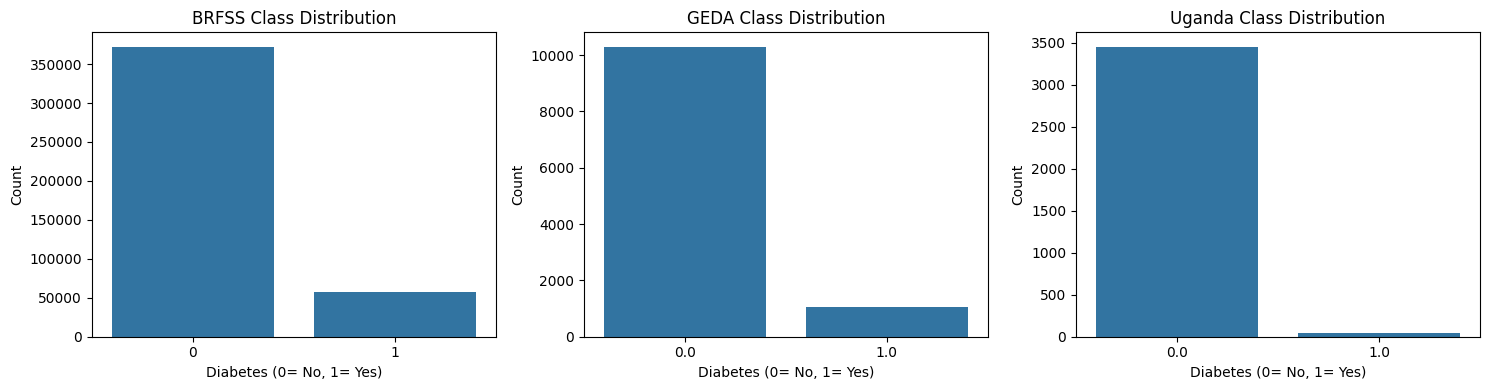

In [ ]:
#Plot class distribution

fig, axes =plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, datasets.items()):
    data= df.dropna(subset=[target]).copy()
    sns.countplot(x=data[target], ax=ax)
    ax.set_title(f"{name} Class Distribution")
    ax.set_xlabel("Diabetes (0= No, 1= Yes)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
#Common preprocessing function that will fill in missing values with the most frequent category
#Why most frequent? because age & BMI are grouped categories not continuous variables

def make_preprocessor(feature_list):
    return ColumnTransformer(
        transformers=[
             ("num", Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))]), feature_list)
         ]
    )


In [ ]:
#Baseline logistic regression function

def run_baseline_logistic(df, dataset_name, feature_list, target_col):
    data= df.dropna(subset=[target_col]).copy()

    x = data[feature_list]
    y = data[target_col]

    x_train, x_test, y_train, y_test =train_test_split(
        x, y, test_size=0.3, stratify=y, random_state=42
    )


    preprocessor =make_preprocessor(feature_list)

    model = Pipeline([
       ("prep", preprocessor),
       ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))

    ])

    model.fit(x_train, y_train)

    proba =model.predict_proba(x_test)[:,1]
    pred=(proba >=0.5).astype(int)

    results={
        "Dataset": dataset_name,
        "AUC": roc_auc_score(y_test, proba),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    }

    return results, model, x_test, y_test, pred, proba

In [ ]:
#Running baseline logistic regression on all 3 datasets
baseline_results =[]
baseline_objects ={}

for name, df in datasets.items():
    results, model, x_test, y_test, pred, proba =run_baseline_logistic(df, name, features, target)
    baseline_results.append(results)
    baseline_objects[name] ={
         "model": model,
         "x_test": x_test,
         "y_test": y_test,
         "pred": pred,
         "proba": proba
    }
baseline_results_df =pd.DataFrame(baseline_results)
baseline_results_df

,Dataset,AUC,Precision,Recall,F1
0,BRFSS,0.785146,0.275475,0.728067,0.399712
1,GEDA,0.793688,0.217936,0.719745,0.334567
2,Uganda,0.625276,0.022581,0.500000,0.043210


In [ ]:
#Creating a balanved subset with the same number of positive and negative cases
def run_balanced_sample_experiment(df, dataset_name, feature_list, target_col, n_per_class=100):
    data=df.dropna(subset=[target_col]).copy()

    pos =data[data[target_col] ==1]
    neg =data[data[target_col] ==0]

    n =min(n_per_class, len(pos), len(neg))

    pos_sample =pos.sample(n=n, random_state=42)
    neg_sample =neg.sample(n=n, random_state=42)

    balanced =pd.concat([pos_sample, neg_sample], axis=0).sample(frac=1, random_state=42)

    x= balanced[feature_list]
    y= balanced[target_col]

    x_train, x_test, y_train, y_test =train_test_split(
        x,y, test_size=0.3, stratify=y, random_state=42
    )
    preprocessor =make_preprocessor (feature_list)

    model =Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=1000))
    ])

    model.fit(x_train, y_train)

    proba =model.predict_proba(x_test)[:,1]
    pred = (proba >=0.5).astype(int)

    results= {
        "Dataset": dataset_name,
        "Balanced_n_per_class": n,
        "AUC": roc_auc_score(y_test, proba),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    }

    return results, model, x_test, y_test, pred, proba

In [ ]:
#Running balanced sample experiments on all 3 datasets

balanced_results =[]
balanced_objects ={}

for name, df in datasets.items():
    results, model, x_test, y_test, pred, proba= run_balanced_sample_experiment(
        df, name, features, target, n_per_class=100
    )
    balanced_results.append(results)
    balanced_objects[name]={
        "model": model,
        "x_test": x_test,
        "y_test": y_test,
        "pred": pred,
        "proba": proba
    }
balanced_results_df=pd.DataFrame(balanced_results)
balanced_results_df

,Dataset,Balanced_n_per_class,AUC,Precision,Recall,F1
0,BRFSS,100,0.875000,0.838710,0.866667,0.852459
1,GEDA,100,0.718333,0.594595,0.733333,0.656716
2,Uganda,46,0.556122,0.500000,0.428571,0.461538


In [ ]:
#Confusion matrix
def plot_conf_matrix(y_true, y_pred, title):
    cm=confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Predicted No", "Predicted Yes"],
        yticklabels=["Actual No", "Actual Yes"]
    )
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


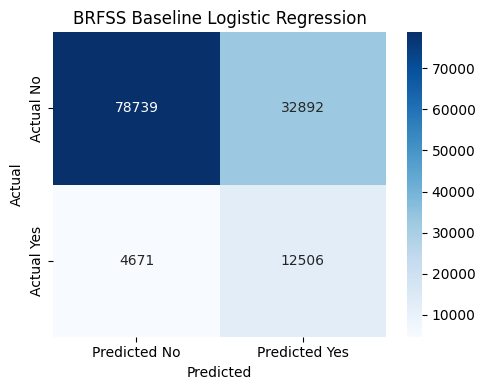

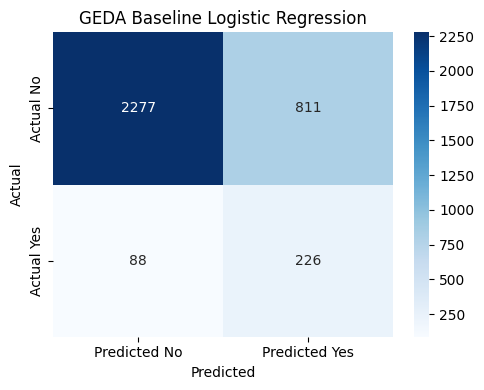

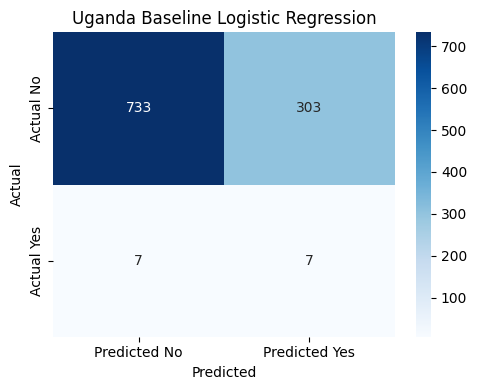

In [ ]:
for name, obj in baseline_objects.items():
    plot_conf_matrix(obj["y_test"], obj["pred"], f"{name} Baseline Logistic Regression")


In [ ]:
#False positive analysis function
def analyze_false_positives(x_test, y_test, pred, proba, feature_list):
    analysis_df =x_test.copy()
    analysis_df["actual"] =y_test.values
    analysis_df["predicted"] = pred
    analysis_df["predicted_proba"] =proba

    false_positives =analysis_df[(analysis_df["actual"] ==0) & (analysis_df["predicted"] ==1)]
    true_negatives =analysis_df[(analysis_df["actual"] ==0) & (analysis_df["predicted"] ==0)]

    return false_positives, true_negatives

In [ ]:
#Run false positive analysis for all
for name, obj in baseline_objects.items():
    fp, tn =analyze_false_positives(
        obj["x_test"], obj["y_test"], obj["pred"], obj["proba"], features
    )

    print(f"\n==== {name} ====")
    print("Number of false positives:", len(fp))
    print("\nFalse positivies mean profile:")
    print(fp[features].mean())

    print("\nTrue negatives mean profile:")
    print(tn[features].mean())



==== BRFSS ====
Number of false positives: 32892

False positivies mean profile:
age_group            2.772924
sex_male             0.469020
bmi_group            2.375893
hypertension         0.884987
current_smoker       0.156109
physically_active    0.617294
dtype: float64

True negatives mean profile:
age_group            1.953060
sex_male             0.406838
bmi_group            1.672127
hypertension         0.142255
current_smoker       0.142492
physically_active    0.815748
dtype: float64

==== GEDA ====
Number of false positives: 811

False positivies mean profile:
age_group            2.490752
sex_male             0.569667
bmi_group            1.443210
hypertension         0.802469
current_smoker       0.172626
physically_active    0.543773
dtype: float64

True negatives mean profile:
age_group            1.649100
sex_male             0.419851
bmi_group            1.058667
hypertension         0.078691
current_smoker       0.235062
physically_active    0.810466
dtype: float64

In [ ]:
#Grid search tuning function for Logistic regression
def tune_logistic_regression(df, dataset_name, feature_list, target_col):
    data=df.dropna(subset=[target_col]).copy()

    x= data[feature_list]
    y= data[target_col]

    x_train, x_test, y_train, y_test =train_test_split(
        x,y, test_size=0.3, stratify=y, random_state=42
    )
    preprocessor =make_preprocessor (feature_list)

    pipe =Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=1000))
    ])

    param_grid={
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__class_weight": [None, "balanced"],
        "clf__solver": ["liblinear", "lbfgs"]
    }

    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid= GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(x_train, y_train)

    best_model =grid.best_estimator_
    proba =best_model.predict_proba(x_test)[:,1]
    pred =(proba>=0.5).astype(int)


    results= {
        "Dataset": dataset_name,
        "Best_Params": grid.best_params_,
        "AUC": roc_auc_score(y_test, proba),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    }

    return results, best_model, x_test, y_test, pred, proba

In [ ]:
#Run grid search on all 3
tuned_results =[]
tuned_objects ={}

for name, df in datasets.items():
    results, model, x_test, y_test, pred, proba= tune_logistic_regression(
        df, name, features, target
    )
    tuned_results.append(results)
    tuned_objects[name]={
        "model": model,
        "x_test": x_test,
        "y_test": y_test,
        "pred": pred,
        "proba": proba
    }
tuned_results_df=pd.DataFrame(tuned_results)
tuned_results_df

,Dataset,Best_Params,AUC,Precision,Recall,F1
0,BRFSS,"{'clf__C': 0.01, 'clf__class_weight': 'balance...",0.785146,0.275475,0.728067,0.399712
1,GEDA,"{'clf__C': 1, 'clf__class_weight': 'balanced',...",0.793740,0.217936,0.719745,0.334567
2,Uganda,"{'clf__C': 0.01, 'clf__class_weight': 'balance...",0.635135,0.023490,0.500000,0.044872


In [ ]:
#Generic model comparison
def evaluate_model(model, x_train, x_test, y_train, y_test, model_name, dataset_name):
    model.fit(x_train, y_train)
    proba =model.predict_proba(x_test)[:,1]
    pred =(proba>=0.5).astype(int)

    return{
        "Dataset": dataset_name,
        "Model": model_name,
        "AUC": roc_auc_score(y_test, proba),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    }


In [ ]:
#Comparing Logistic Regression, Random Forest, Gradient Boosting for each dataset
comparison_results =[]

for name, df in datasets.items():
    data =df.dropna(subset=[target]).copy()

    x= data[features]
    y= data[target]

    x_train, x_test, y_train, y_test =train_test_split(
        x,y, test_size=0.3, stratify=y, random_state=42
    )

    preprocessor =make_preprocessor(features)

    #Tuned logistic regression from previous step
    best_log_model =tuned_objects[name]["model"]
    comparison_results.append(
       evaluate_model(best_log_model, x_train, x_test, y_train, y_test, "LogisticRegression_tuned", name)
   )

    #Random Forest
    rf_model =Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            class_weight="balanced",
            random_state=42
        ))
    ])
    comparison_results.append(
        evaluate_model(rf_model, x_train, x_test, y_train, y_test, "RandomForest", name)

    )

    #Gradient Boosting
    gb_model =Pipeline([
        ("prep", preprocessor),
        ("clf", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ])
    comparison_results.append(
        evaluate_model(gb_model, x_train, x_test, y_train, y_test, "GradientBoosting", name)
    )

comparison_results_df =pd.DataFrame(comparison_results)
comparison_results_df

,Dataset,Model,AUC,Precision,Recall,F1
0,BRFSS,LogisticRegression_tuned,0.785146,0.275475,0.728067,0.399712
1,BRFSS,RandomForest,0.786927,0.255213,0.795133,0.386403
2,BRFSS,GradientBoosting,0.788892,0.000000,0.000000,0.000000
3,GEDA,LogisticRegression_tuned,0.793740,0.217936,0.719745,0.334567
4,GEDA,RandomForest,0.794309,0.199354,0.786624,0.318094
5,GEDA,GradientBoosting,0.793539,0.454545,0.015924,0.030769
6,Uganda,LogisticRegression_tuned,0.635135,0.023490,0.500000,0.044872
7,Uganda,RandomForest,0.535370,0.016575,0.214286,0.030769
8,Uganda,GradientBoosting,0.527441,0.000000,0.000000,0.000000


In [ ]:
#1000 patient scenario function

def scale_confusion_to_1000(y_true, y_pred):
    tn, fp, fn, tp =confusion_matrix(y_true, y_pred).ravel()
    total =tn + fp + fn + tp

    scaled ={
        "True negatives per 1000": round(tn /total *1000),
        "False positives per 1000": round(fp /total *1000),
        "False negatives per 1000": round(fn /total *1000),
        "True positives per 1000": round(tp /total *1000),

    }
    return scaled

In [ ]:
#Apply 1000 patient scenario to tuned Logistic Regression for all 3
for name, obj in tuned_objects.items():
    print(f"\n==== {name} ====")
    scaled =scale_confusion_to_1000(obj["y_test"], obj["pred"])
    print(scaled)


==== BRFSS ====
{'True negatives per 1000': 611, 'False positives per 1000': 255, 'False negatives per 1000': 36, 'True positives per 1000': 97}

==== GEDA ====
{'True negatives per 1000': 669, 'False positives per 1000': 238, 'False negatives per 1000': 26, 'True positives per 1000': 66}

==== Uganda ====
{'True negatives per 1000': 710, 'False positives per 1000': 277, 'False negatives per 1000': 7, 'True positives per 1000': 7}


**BRFSS:**

If the model is applied to 1000 patients:

-it correctly clears 611 people

-it wrongly flags 255 people as diabetes

-it misses 36 real diabetes cases

-it correctly identifies 97 diabetes cases

**GEDA:**

If the model is applied to 1000 patients:

-669 are correctly cleared

-238 are false alarms

-26 are missed diabetes cases

-66 are correctly identified diabetes cases

**Uganda:**

The Uganda result is much less useful in practice:

-277 false positives

-only 7 true positives

-7 false negatives

In a hospital, the model may be useful only if the number of false positives is acceptable relative to the number of true positives found. BRFSS and GEDA show a more reasonable screening tradeoff while Uganda currently produces too many false positives relative to its true-positive yield.

In [ ]:
#Baseline Logistic Regression
baseline_results_df

,Dataset,AUC,Precision,Recall,F1
0,BRFSS,0.785146,0.275475,0.728067,0.399712
1,GEDA,0.793688,0.217936,0.719745,0.334567
2,Uganda,0.625276,0.022581,0.500000,0.043210


**Baseline results interpretation**

**BRFSS:** the model separates diabetes and non-diabetes reasonably well but precision is low. This means it catches many true diabetes cases but it also wrongly flags many people who do not have diabetes.

**GEDA:** very similar to BRFSS(good discrimination, good recall, low precision), so the model behaves more like a screening model than a precise diagnostic model.

**Uganda:** much weaker AUC, extremely low precision, moderate recall, this is because the dataset is much smaller, there are very few diabetes positive cases.

In [ ]:
#Balanced sample experiment
balanced_results_df

,Dataset,Balanced_n_per_class,AUC,Precision,Recall,F1
0,BRFSS,100,0.875000,0.838710,0.866667,0.852459
1,GEDA,100,0.718333,0.594595,0.733333,0.656716
2,Uganda,46,0.556122,0.500000,0.428571,0.461538


**After balancing the classes:**

-precision rises a lot

-F1 rises a lot

-the model behaves much better

**BRFSS:** precision jumps from 0.275 to 0.839, that is a huge change.

**GEDA:** precision jumps from 0.218 to 0.595, a strong improvement

**Uganda:** is still unstable but the precision rises from 0.023 to 0.500



In [ ]:
#Tuned Logistics Regression
tuned_results_df

,Dataset,Best_Params,AUC,Precision,Recall,F1
0,BRFSS,"{'clf__C': 0.01, 'clf__class_weight': 'balance...",0.785146,0.275475,0.728067,0.399712
1,GEDA,"{'clf__C': 1, 'clf__class_weight': 'balanced',...",0.793740,0.217936,0.719745,0.334567
2,Uganda,"{'clf__C': 0.01, 'clf__class_weight': 'balance...",0.635135,0.023490,0.500000,0.044872


**BRFSS:** tuning did not materially improve the results.

**GEDA:** also almost unchanged

**Uganda:** AUC improved a little but precision and recall remain almost the same.

Grid search did not reduce the false positive issue in BRFSS or GEDA.

In [ ]:
#Multi-model comparison
comparison_results_df

,Dataset,Model,AUC,Precision,Recall,F1
0,BRFSS,LogisticRegression_tuned,0.785146,0.275475,0.728067,0.399712
1,BRFSS,RandomForest,0.786927,0.255213,0.795133,0.386403
2,BRFSS,GradientBoosting,0.788892,0.000000,0.000000,0.000000
3,GEDA,LogisticRegression_tuned,0.793740,0.217936,0.719745,0.334567
4,GEDA,RandomForest,0.794309,0.199354,0.786624,0.318094
5,GEDA,GradientBoosting,0.793539,0.454545,0.015924,0.030769
6,Uganda,LogisticRegression_tuned,0.635135,0.023490,0.500000,0.044872
7,Uganda,RandomForest,0.535370,0.016575,0.214286,0.030769
8,Uganda,GradientBoosting,0.527441,0.000000,0.000000,0.000000


**BRFSS:**

-Logistic regression & Random forest are quite similar in AUC

-Random forest gives higher recall

-Precision is slightly lower

-Gradient Boosting fails completely at the default threshold

**GEDA:**

-Logistic regression & random forest are again quite similar in AUC.

-Random forest gives higher recall

-But lower precision

-Gradient Boosting gives very high precision but almost no recall


Uganda:

-Logistic Regression is the strongest of the three

-Random forest is weaker

-Gradient Boosting essentially collapses at the threshold used